# ToN-IoT GNN vs QGNN Training Notebook

This notebook is prepared for Google Colab and expects the CSV files to already be uploaded into `/content`.

Adjusted for lighter Colab usage:
- `MAX_SAMPLES_PER_CLASS = 8000`
- `BATCH_SIZE = 256`

In [ ]:
!pip -q install pennylane torchmetrics scikit-learn seaborn matplotlib

In [ ]:
import heapq
heap = []
heapq.heappush(heap, (3, 3))
heapq.heappush(heap, (7, 4))
heapq.heappush(heap, (7, 2))
heapq.heappush(heap, (7, 4))

print(heap)

[(3, 3), (7, 4), (7, 2), (7, 4)]


In [ ]:

# Cell 1 - Imports, config, and reproducibility

import os
import random
import warnings
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

import pennylane as qml

warnings.filterwarnings("ignore")
os.environ["PYTHONHASHSEED"] = "42"

SEED = 42
DATA_DIR = "/content"
CSV_FILES = [
    "password.csv",
    "scanning.csv",
    "mitm.csv",
    "benign_tot.csv",
    "ransomware.csv",
    "backdoor.csv",
    "dos.csv",
    "injection.csv",
    "xss.csv",
    "ddos.csv",
]
LABEL_MAP = {
    "benign_tot.csv": "benign",
    "ransomware.csv": "ransomware",
    "backdoor.csv": "backdoor",
    "dos.csv": "dos",
    "injection.csv": "injection",
    "xss.csv": "xss",
    "ddos.csv": "ddos",
    "scanning.csv": "scanning",
    "mitm.csv": "mitm",
    "password.csv": "password",
}

MAX_SAMPLES_PER_CLASS = 8000
FEATURE_K = 40
TEST_SIZE = 0.20
VAL_SIZE = 0.10
BATCH_SIZE = 256
EPOCHS = 30
PATIENCE = 7
HIDDEN_DIM = 160
DROPOUT = 0.20
K_NEIGHBORS = 8
N_QUBITS = 4
Q_DEPTH = 2
QUANTUM_CHUNK = 96
LR_GNN = 2e-3
LR_QGNN = 1.2e-3
WEIGHT_DECAY = 1e-4

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

print("Device:", device)
print("Torch version:", torch.__version__)
print("PennyLane version:", qml.__version__)


Device: cuda
Torch version: 2.10.0+cu128
PennyLane version: 0.44.1


In [ ]:

# Cell 2 - Load all CSV files and create the target labels

dfs = []
for file_name in CSV_FILES:
    file_path = os.path.join(DATA_DIR, file_name)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing file: {file_path}")

    temp_df = pd.read_csv(file_path, low_memory=False)
    temp_df["target_label"] = LABEL_MAP[file_name]

    if MAX_SAMPLES_PER_CLASS is not None and len(temp_df) > MAX_SAMPLES_PER_CLASS:
        temp_df = temp_df.sample(n=MAX_SAMPLES_PER_CLASS, random_state=SEED)

    dfs.append(temp_df)
    print(f"Loaded {file_name:<18} -> {temp_df.shape}")

data = pd.concat(dfs, ignore_index=True)
data = data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("\nFinal merged shape:", data.shape)
print("\nClass distribution:")
print(data["target_label"].value_counts())


Loaded password.csv       -> (8000, 45)
Loaded scanning.csv       -> (8000, 45)
Loaded mitm.csv           -> (1043, 45)
Loaded benign_tot.csv     -> (8000, 45)
Loaded ransomware.csv     -> (8000, 45)
Loaded backdoor.csv       -> (8000, 45)
Loaded dos.csv            -> (8000, 45)
Loaded injection.csv      -> (8000, 45)
Loaded xss.csv            -> (8000, 45)
Loaded ddos.csv           -> (8000, 45)

Final merged shape: (73043, 45)

Class distribution:
target_label
dos           8000
ddos          8000
password      8000
xss           8000
backdoor      8000
ransomware    8000
scanning      8000
injection     8000
benign        8000
mitm          1043
Name: count, dtype: int64


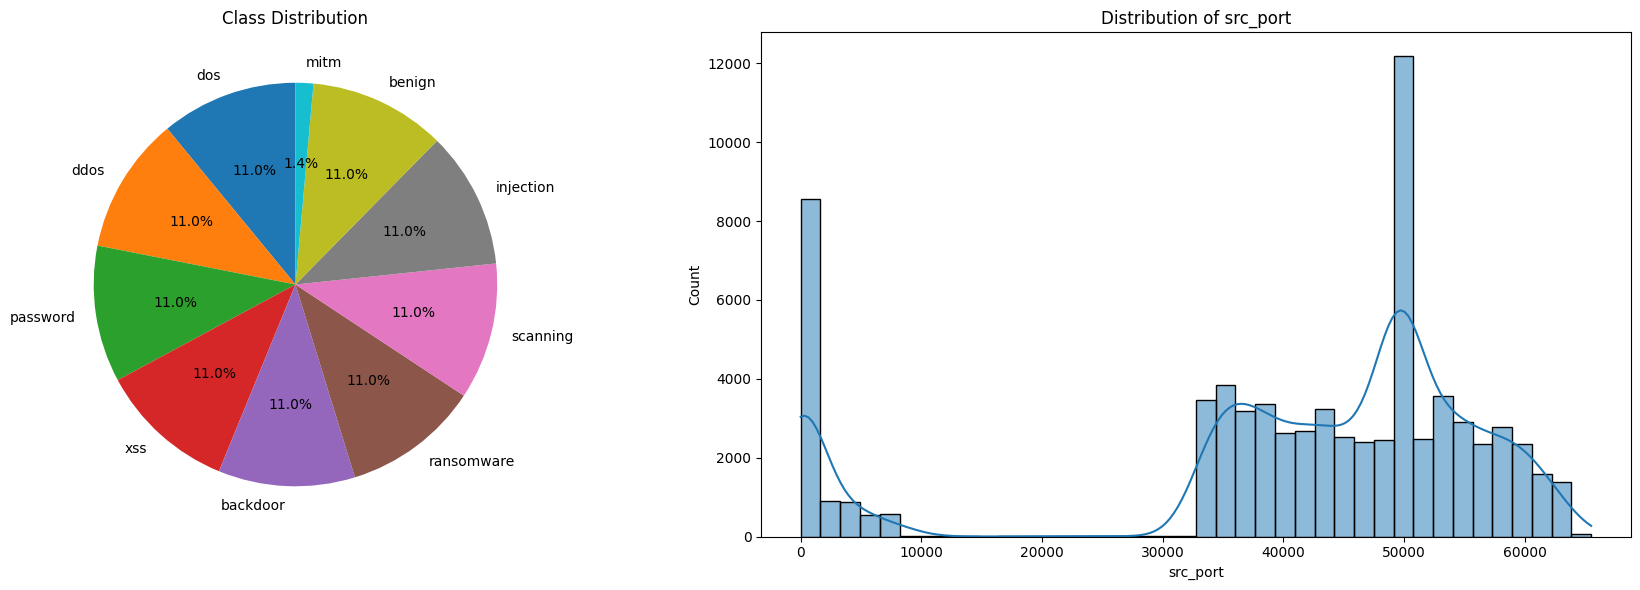

Columns: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type', 'target_label']


In [ ]:

# Cell 3 - Quick EDA

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

class_counts = data["target_label"].value_counts()
axes[0].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Class Distribution")

numeric_candidates = [c for c in ["src_port", "dst_port", "src_bytes", "dst_bytes", "duration"] if c in data.columns]
chosen_numeric = numeric_candidates[0] if numeric_candidates else data.select_dtypes(include=np.number).columns[0]
sns.histplot(data[chosen_numeric].fillna(0), bins=40, kde=True, ax=axes[1])
axes[1].set_title(f"Distribution of {chosen_numeric}")
axes[1].set_xlabel(chosen_numeric)

plt.tight_layout()
plt.show()

print("Columns:", list(data.columns))


In [ ]:

# Cell 4 - Feature engineering + cleaning + encoding + scaling + feature selection

def extract_ip_parts(series, prefix):
    s = series.fillna("0.0.0.0").astype(str)
    parts = s.str.extract(r"(\d+)\.(\d+)\.(\d+)\.(\d+)")
    parts = parts.fillna(0).astype(np.float32)
    parts.columns = [f"{prefix}_p1", f"{prefix}_p2", f"{prefix}_p3", f"{prefix}_p4"]
    parts[f"{prefix}_is_private"] = s.str.startswith(
        ("10.", "192.168.", "172.16.", "172.17.", "172.18.", "172.19.", "172.2")
    ).astype(np.float32)
    return parts

df = data.copy()

for col in ["label", "type"]:
    if col in df.columns:
        df = df.drop(columns=col)

if "src_ip" in df.columns:
    src_ip_parts = extract_ip_parts(df["src_ip"], "src_ip")
    df = pd.concat([df.drop(columns=["src_ip"]), src_ip_parts], axis=1)

if "dst_ip" in df.columns:
    dst_ip_parts = extract_ip_parts(df["dst_ip"], "dst_ip")
    df = pd.concat([df.drop(columns=["dst_ip"]), dst_ip_parts], axis=1)

text_len_cols = [
    "dns_query",
    "http_uri",
    "http_user_agent",
    "ssl_subject",
    "ssl_issuer",
    "weird_addl",
]
for col in text_len_cols:
    if col in df.columns:
        df[f"{col}_len"] = df[col].fillna("").astype(str).str.len().astype(np.float32)

categorical_cols = [c for c in df.select_dtypes(include="object").columns if c != "target_label"]
encoding_info = {}

for col in categorical_cols:
    nunique = df[col].nunique(dropna=False)

    if nunique <= 80:
        encoded, uniques = pd.factorize(df[col].fillna("missing").astype(str))
        df[col] = encoded.astype(np.int32)
        encoding_info[col] = f"factorize({nunique})"
    else:
        freq = df[col].fillna("missing").astype(str).value_counts(normalize=True)
        df[col] = df[col].fillna("missing").astype(str).map(freq).astype(np.float32)
        encoding_info[col] = f"frequency({nunique})"

y = df["target_label"].copy()
X = df.drop(columns=["target_label"]).replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("Feature matrix before selection:", X.shape)
print("Encoding summary:")
for k, v in encoding_info.items():
    print(f"  {k:<22} -> {v}")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)
print("\nClasses:", list(label_encoder.classes_))

selector_sample_size = min(50000, len(X))
selector_idx = np.random.RandomState(SEED).choice(len(X), size=selector_sample_size, replace=False)

selector = SelectKBest(score_func=f_classif, k=min(FEATURE_K, X.shape[1]))
selector.fit(X.iloc[selector_idx], y_encoded[selector_idx])

selected_feature_mask = selector.get_support()
selected_feature_names = X.columns[selected_feature_mask].tolist()
X_selected = selector.transform(X).astype(np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected).astype(np.float32)

print("\nFeature matrix after selection:", X_scaled.shape)
print("Selected features:")
print(selected_feature_names)


Feature matrix before selection: (73043, 56)
Encoding summary:
  proto                  -> factorize(3)
  service                -> factorize(9)
  conn_state             -> factorize(13)
  dns_query              -> frequency(421)
  dns_AA                 -> factorize(3)
  dns_RD                 -> factorize(3)
  dns_RA                 -> factorize(3)
  dns_rejected           -> factorize(3)
  ssl_version            -> factorize(4)
  ssl_cipher             -> factorize(5)
  ssl_resumed            -> factorize(3)
  ssl_established        -> factorize(3)
  ssl_subject            -> factorize(2)
  ssl_issuer             -> factorize(2)
  http_trans_depth       -> factorize(5)
  http_method            -> factorize(4)
  http_uri               -> factorize(40)
  http_version           -> factorize(2)
  http_user_agent        -> factorize(23)
  http_orig_mime_types   -> factorize(3)
  http_resp_mime_types   -> factorize(9)
  weird_name             -> factorize(7)
  weird_addl             -> fa

In [ ]:

# Cell 5 - Train/validation/test split + DataLoaders

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_encoded,
)

val_ratio_from_train = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=val_ratio_from_train,
    random_state=SEED,
    stratify=y_train_full,
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

class_counts = np.bincount(y_train)
class_weights = class_counts.sum() / np.maximum(class_counts, 1)
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

sample_weights = 1.0 / np.maximum(class_counts[y_train], 1)
sample_weights_t = torch.tensor(sample_weights, dtype=torch.double)
train_sampler = WeightedRandomSampler(
    weights=sample_weights_t,
    num_samples=len(sample_weights_t),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

input_dim = X_train.shape[1]
print("Input dim:", input_dim)
print("Class counts:", class_counts)
print("Class weights:", class_weights.round(3))


Train: (51129, 40) (51129,)
Val  : (7305, 40) (7305,)
Test : (14609, 40) (14609,)
Input dim: 40
Class counts: [5600 5600 5600 5600 5600  729 5600 5600 5600 5600]
Class weights: [0.599 0.599 0.599 0.599 0.599 4.605 0.599 0.599 0.599 0.599]


In [ ]:

# Cell 6 - Define GNN and QGNN models

def build_knn_graph(x, k=8):
    x = F.normalize(x, p=2, dim=1)
    sim = x @ x.T
    sim.fill_diagonal_(-1e9)

    k = min(k, x.size(0) - 1)
    knn_idx = sim.topk(k=k, dim=1).indices

    adj = torch.zeros((x.size(0), x.size(0)), device=x.device, dtype=x.dtype)
    adj.scatter_(1, knn_idx, 1.0)
    adj = torch.maximum(adj, adj.T)
    adj.fill_diagonal_(1.0)

    deg = adj.sum(dim=1).clamp(min=1.0)
    deg_inv_sqrt = deg.pow(-0.5)
    adj_norm = deg_inv_sqrt.unsqueeze(1) * adj * deg_inv_sqrt.unsqueeze(0)
    return adj_norm


class GraphBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.2):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
        self.norm = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)
        self.residual = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x, adj):
        h = adj @ x
        h = self.lin(h)
        h = self.norm(h)
        h = F.gelu(h)
        h = self.dropout(h)
        return h + self.residual(x)


class BaseTabularGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=160, dropout=0.2, k_neighbors=8):
        super().__init__()
        self.k_neighbors = k_neighbors
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.g1 = GraphBlock(hidden_dim, hidden_dim, dropout)
        self.g2 = GraphBlock(hidden_dim, hidden_dim, dropout)
        self.g3 = GraphBlock(hidden_dim, hidden_dim, dropout)

    def encode(self, x):
        h = self.encoder(x)
        adj = build_knn_graph(h, k=self.k_neighbors)
        h = self.g1(h, adj)
        h = self.g2(h, adj)
        h = self.g3(h, adj)
        return h


class ClassicalGNN(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=160, dropout=0.2, k_neighbors=8):
        super().__init__()
        self.backbone = BaseTabularGNN(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
            k_neighbors=k_neighbors,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        h = self.backbone.encode(x)
        global_context = h.mean(dim=0, keepdim=True).expand_as(h)
        logits = self.classifier(torch.cat([h, global_context], dim=1))
        return logits


quantum_device = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(quantum_device, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


weight_shapes = {"weights": (Q_DEPTH, N_QUBITS, 3)}


class QuantumHead(nn.Module):
    def __init__(self, hidden_dim, n_qubits, chunk_size=96):
        super().__init__()
        self.pre_q = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, n_qubits),
            nn.Tanh(),
        )
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.chunk_size = chunk_size

    def forward(self, h):
        q_in = self.pre_q(h)
        q_out_chunks = []
        for chunk in torch.split(q_in, self.chunk_size, dim=0):
            q_out_chunks.append(self.quantum_layer(chunk))
        q_out = torch.cat(q_out_chunks, dim=0)
        return q_out


class QuantumGNN(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=160, dropout=0.2, k_neighbors=8):
        super().__init__()
        self.backbone = BaseTabularGNN(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
            k_neighbors=k_neighbors,
        )
        self.quantum_head = QuantumHead(hidden_dim=hidden_dim, n_qubits=N_QUBITS, chunk_size=QUANTUM_CHUNK)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2 + N_QUBITS, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        h = self.backbone.encode(x)
        q_out = self.quantum_head(h)
        global_context = h.mean(dim=0, keepdim=True).expand_as(h)
        logits = self.classifier(torch.cat([h, global_context, q_out], dim=1))
        return logits


classical_model = ClassicalGNN(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    k_neighbors=K_NEIGHBORS,
).to(device)

quantum_model = QuantumGNN(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    k_neighbors=K_NEIGHBORS,
).to(device)

loss_fn = nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=0.05)

optimizer_gnn  = torch.optim.AdamW(classical_model.parameters(), lr=LR_GNN,  weight_decay=WEIGHT_DECAY)
optimizer_qgnn = torch.optim.AdamW(quantum_model.parameters(),   lr=LR_QGNN, weight_decay=WEIGHT_DECAY)

scheduler_gnn  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_gnn,  mode="max", factor=0.5, patience=2)
scheduler_qgnn = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_qgnn, mode="max", factor=0.5, patience=2)

print(classical_model)
print()
print(quantum_model)


ClassicalGNN(
  (backbone): BaseTabularGNN(
    (encoder): Sequential(
      (0): Linear(in_features=40, out_features=160, bias=True)
      (1): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
    )
    (g1): GraphBlock(
      (lin): Linear(in_features=160, out_features=160, bias=False)
      (norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
    (g2): GraphBlock(
      (lin): Linear(in_features=160, out_features=160, bias=False)
      (norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
    (g3): GraphBlock(
      (lin): Linear(in_features=160, out_features=160, bias=False)
      (norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
 

In [ ]:

# Cell 7 - Train both models

def get_epoch_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "acc": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }


def run_one_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    all_targets = []
    all_preds = []
    all_probs = []
    running_loss = 0.0
    seen = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = loss_fn(logits, yb)

        if train_mode:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        seen += batch_size

        all_targets.append(yb.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)

    metrics = get_epoch_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / max(seen, 1)
    metrics["y_true"] = y_true
    metrics["y_pred"] = y_pred
    metrics["y_prob"] = y_prob
    return metrics


def train_model(model, optimizer, scheduler, train_loader, val_loader, epochs, patience, model_name):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1_weighted": [],
        "val_f1_weighted": [],
        "train_f1_macro": [],
        "val_f1_macro": [],
        "best_val_f1_weighted": [],
    }

    best_state = None
    best_epoch = 0
    best_val_f1 = -1.0
    wait = 0

    for epoch in range(1, epochs + 1):
        train_metrics = run_one_epoch(model, train_loader, optimizer=optimizer)
        val_metrics = run_one_epoch(model, val_loader, optimizer=None)

        scheduler.step(val_metrics["f1_weighted"])

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_f1_weighted"].append(train_metrics["f1_weighted"])
        history["val_f1_weighted"].append(val_metrics["f1_weighted"])
        history["train_f1_macro"].append(train_metrics["f1_macro"])
        history["val_f1_macro"].append(val_metrics["f1_macro"])

        if val_metrics["f1_weighted"] > best_val_f1:
            best_val_f1 = val_metrics["f1_weighted"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        history["best_val_f1_weighted"].append(best_val_f1)

        print(
            f"{model_name} | Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_metrics['loss']:.4f} | val_loss={val_metrics['loss']:.4f} | "
            f"train_acc={train_metrics['acc']:.4f} | val_acc={val_metrics['acc']:.4f} | "
            f"train_f1w={train_metrics['f1_weighted']:.4f} | val_f1w={val_metrics['f1_weighted']:.4f}"
        )

        if wait >= patience:
            print(f"Early stopping triggered for {model_name} at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Best {model_name} weighted F1 on validation: {best_val_f1:.4f} at epoch {best_epoch}")
    return history, best_epoch, best_val_f1


history_gnn, best_epoch_gnn, best_f1_gnn = train_model(
    classical_model, optimizer_gnn, scheduler_gnn, train_loader, val_loader, EPOCHS, PATIENCE, "GNN"
)

history_qgnn, best_epoch_qgnn, best_f1_qgnn = train_model(
    quantum_model, optimizer_qgnn, scheduler_qgnn, train_loader, val_loader, EPOCHS, PATIENCE, "QGNN"
)


GNN | Epoch 01/30 | train_loss=0.6776 | val_loss=0.7928 | train_acc=0.7551 | val_acc=0.8450 | train_f1w=0.7525 | val_f1w=0.8508
GNN | Epoch 02/30 | train_loss=0.5107 | val_loss=0.7012 | train_acc=0.8596 | val_acc=0.8776 | train_f1w=0.8593 | val_f1w=0.8826
GNN | Epoch 03/30 | train_loss=0.4516 | val_loss=0.6487 | train_acc=0.8909 | val_acc=0.8983 | train_f1w=0.8902 | val_f1w=0.9019
GNN | Epoch 04/30 | train_loss=0.4282 | val_loss=0.6380 | train_acc=0.9046 | val_acc=0.9002 | train_f1w=0.9041 | val_f1w=0.9042
GNN | Epoch 05/30 | train_loss=0.4219 | val_loss=0.6231 | train_acc=0.9078 | val_acc=0.9057 | train_f1w=0.9074 | val_f1w=0.9102
GNN | Epoch 06/30 | train_loss=0.4102 | val_loss=0.6155 | train_acc=0.9135 | val_acc=0.9120 | train_f1w=0.9131 | val_f1w=0.9164
GNN | Epoch 07/30 | train_loss=0.4056 | val_loss=0.5949 | train_acc=0.9176 | val_acc=0.9151 | train_f1w=0.9174 | val_f1w=0.9190
GNN | Epoch 08/30 | train_loss=0.3950 | val_loss=0.6046 | train_acc=0.9219 | val_acc=0.9179 | train_f1w=

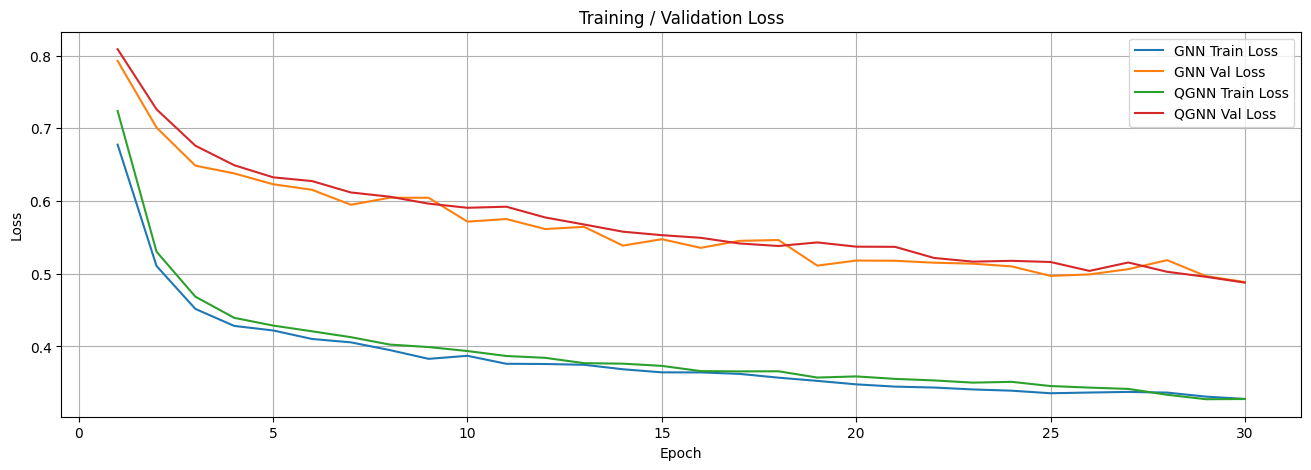

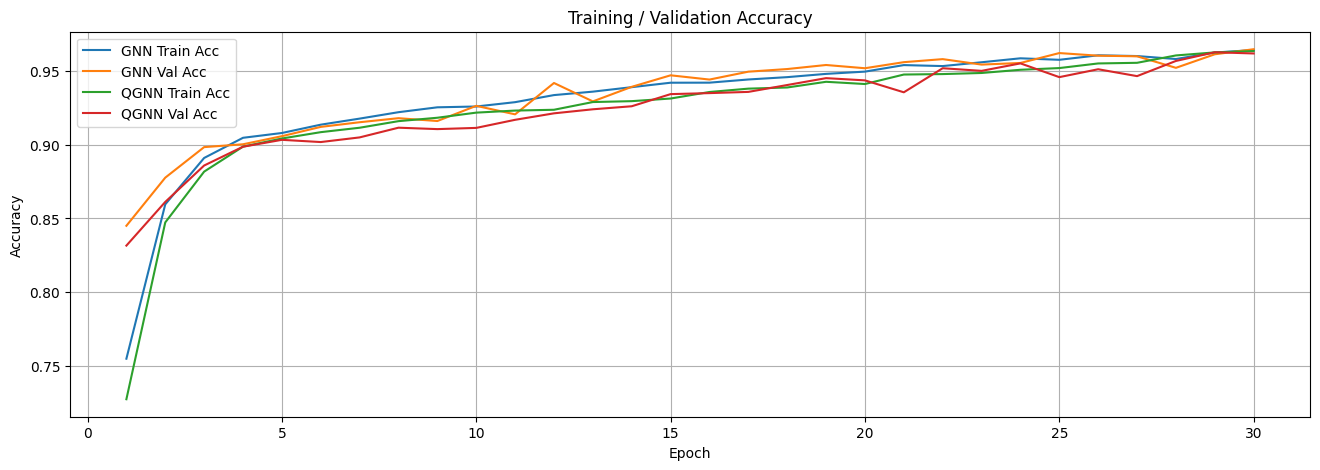

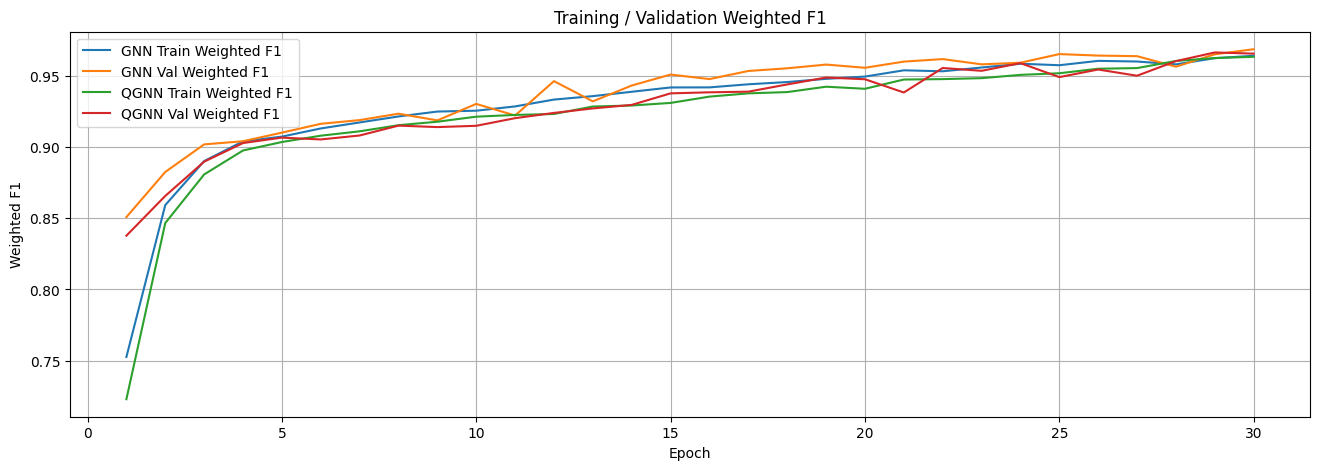

In [ ]:

# Cell 8 - Plot training curves

epochs_gnn = range(1, len(history_gnn["train_loss"]) + 1)
epochs_qgnn = range(1, len(history_qgnn["train_loss"]) + 1)

plt.figure(figsize=(16, 5))
plt.plot(epochs_gnn, history_gnn["train_loss"], label="GNN Train Loss")
plt.plot(epochs_gnn, history_gnn["val_loss"], label="GNN Val Loss")
plt.plot(epochs_qgnn, history_qgnn["train_loss"], label="QGNN Train Loss")
plt.plot(epochs_qgnn, history_qgnn["val_loss"], label="QGNN Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(16, 5))
plt.plot(epochs_gnn, history_gnn["train_acc"], label="GNN Train Acc")
plt.plot(epochs_gnn, history_gnn["val_acc"], label="GNN Val Acc")
plt.plot(epochs_qgnn, history_qgnn["train_acc"], label="QGNN Train Acc")
plt.plot(epochs_qgnn, history_qgnn["val_acc"], label="QGNN Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(16, 5))
plt.plot(epochs_gnn, history_gnn["train_f1_weighted"], label="GNN Train Weighted F1")
plt.plot(epochs_gnn, history_gnn["val_f1_weighted"], label="GNN Val Weighted F1")
plt.plot(epochs_qgnn, history_qgnn["train_f1_weighted"], label="QGNN Train Weighted F1")
plt.plot(epochs_qgnn, history_qgnn["val_f1_weighted"], label="QGNN Val Weighted F1")
plt.xlabel("Epoch")
plt.ylabel("Weighted F1")
plt.title("Training / Validation Weighted F1")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# Cell 9 - Final evaluation on the test set

def evaluate_model(model, loader, model_name):
    metrics = run_one_epoch(model, loader, optimizer=None)
    y_true = metrics["y_true"]
    y_pred = metrics["y_pred"]
    y_prob = metrics["y_prob"]

    print("=" * 100)
    print(f"{model_name} Test Performance")
    print("- Accuracy       :", round(metrics["acc"], 6))
    print("- Macro Precision:", round(metrics["precision_macro"], 6))
    print("- Macro Recall   :", round(metrics["recall_macro"], 6))
    print("- Macro F1       :", round(metrics["f1_macro"], 6))
    print("- Weighted F1    :", round(metrics["f1_weighted"], 6))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=4, zero_division=0))

    return metrics

test_metrics_gnn = evaluate_model(classical_model, test_loader, "GNN")
test_metrics_qgnn = evaluate_model(quantum_model, test_loader, "QGNN")

comparison_df = pd.DataFrame([
    {
        "Model": "GNN",
        "Accuracy": test_metrics_gnn["acc"],
        "Macro F1": test_metrics_gnn["f1_macro"],
        "Weighted F1": test_metrics_gnn["f1_weighted"],
        "Macro Precision": test_metrics_gnn["precision_macro"],
        "Macro Recall": test_metrics_gnn["recall_macro"],
    },
    {
        "Model": "QGNN",
        "Accuracy": test_metrics_qgnn["acc"],
        "Macro F1": test_metrics_qgnn["f1_macro"],
        "Weighted F1": test_metrics_qgnn["f1_weighted"],
        "Macro Precision": test_metrics_qgnn["precision_macro"],
        "Macro Recall": test_metrics_qgnn["recall_macro"],
    },
])

print(comparison_df)


GNN Test Performance
- Accuracy       : 0.963105
- Macro Precision: 0.925133
- Macro Recall   : 0.965481
- Macro F1       : 0.930946
- Weighted F1    : 0.967923

Classification Report:
              precision    recall  f1-score   support

    backdoor     0.9994    0.9975    0.9984      1600
      benign     0.9987    0.9962    0.9975      1600
        ddos     0.9860    0.9656    0.9757      1600
         dos     0.9979    0.9038    0.9485      1600
   injection     0.9784    0.9331    0.9552      1600
        mitm     0.3736    0.9904    0.5426       209
    password     0.9661    0.9806    0.9733      1600
  ransomware     0.9906    0.9931    0.9919      1600
    scanning     0.9806    0.9800    0.9803      1600
         xss     0.9799    0.9144    0.9460      1600

    accuracy                         0.9631     14609
   macro avg     0.9251    0.9655    0.9309     14609
weighted avg     0.9776    0.9631    0.9679     14609

QGNN Test Performance
- Accuracy       : 0.960641
- Macr

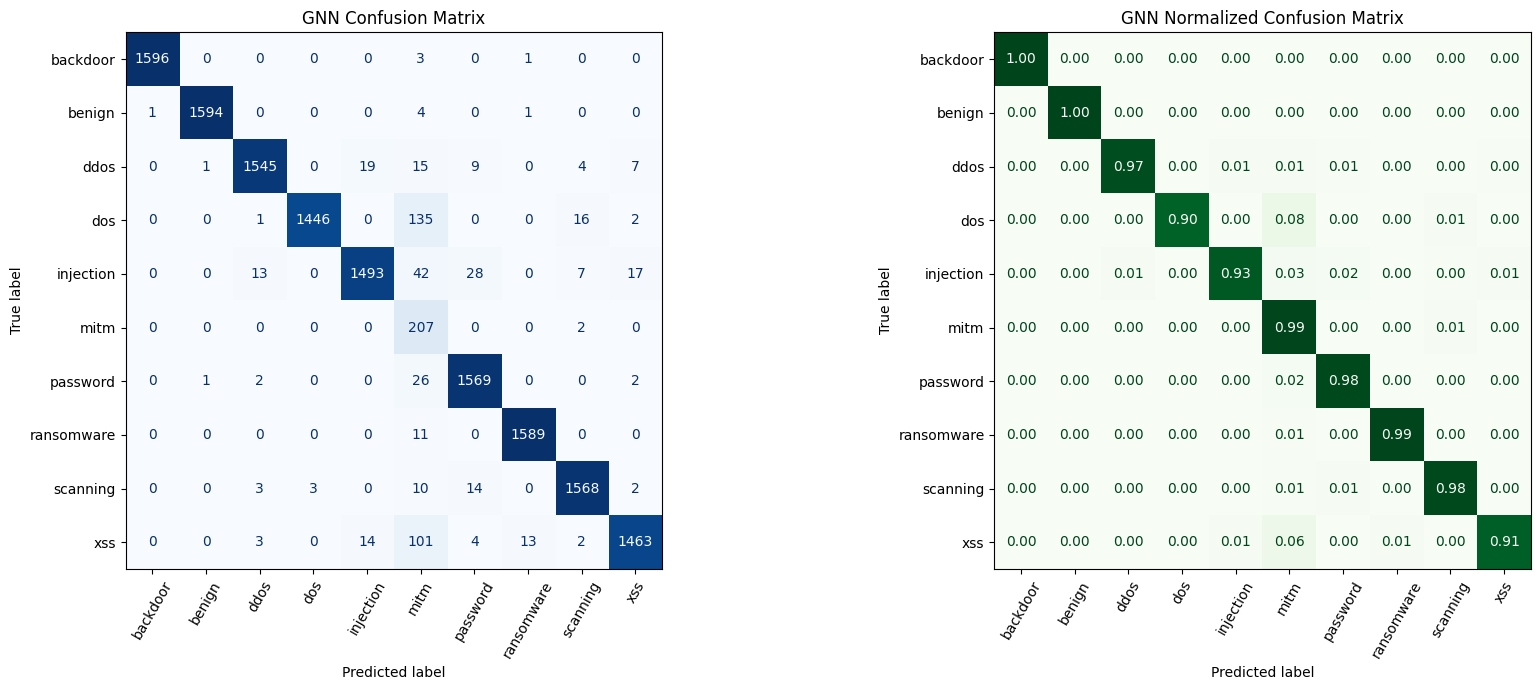

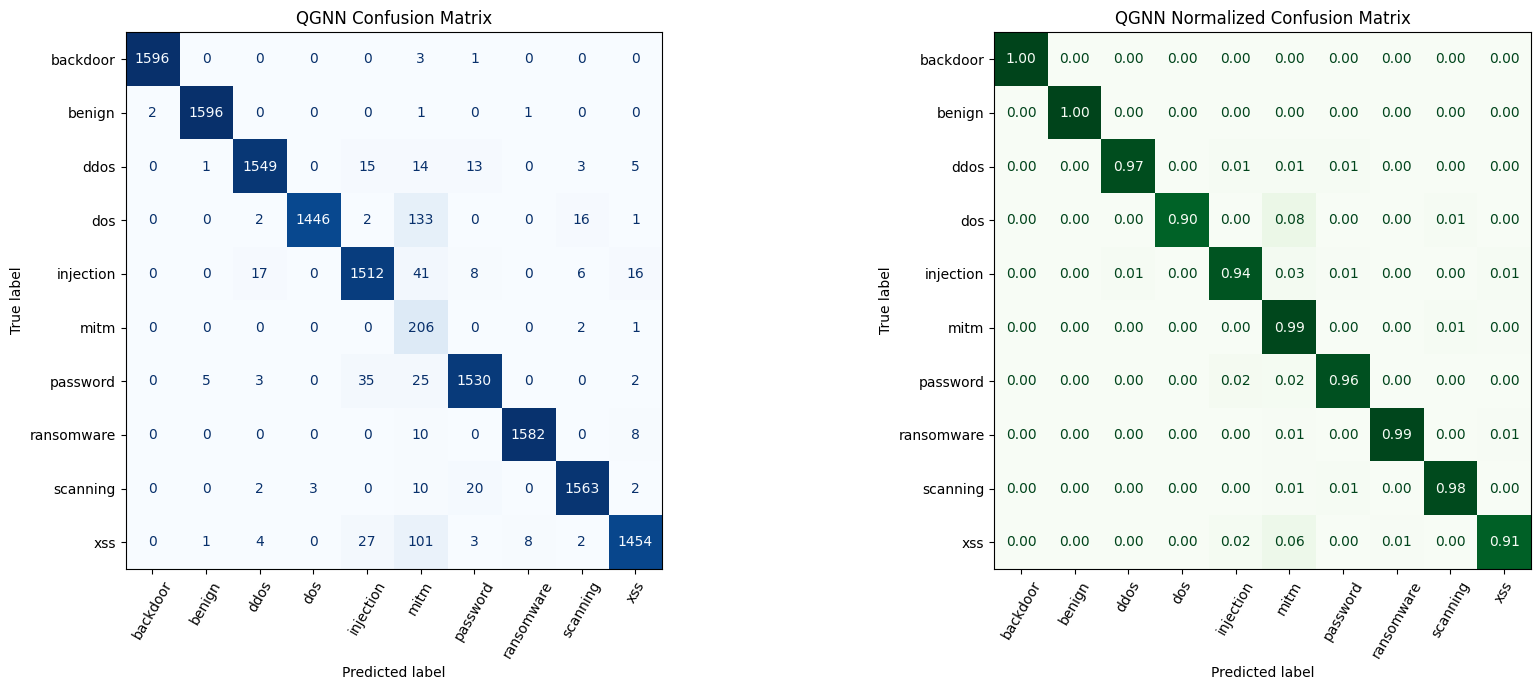

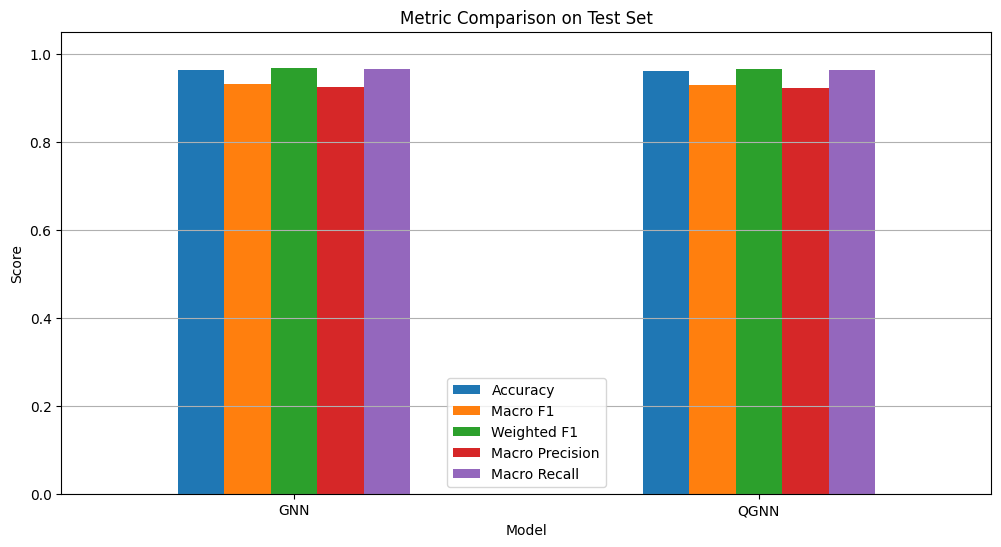

In [ ]:

# Cell 10 - Confusion matrices (absolute + normalized) and metric comparison

def plot_confusion(y_true, y_pred, title_prefix):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp1.plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=60)
    axes[0].set_title(f"{title_prefix} Confusion Matrix")

    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_encoder.classes_)
    disp2.plot(ax=axes[1], cmap="Greens", colorbar=False, xticks_rotation=60, values_format=".2f")
    axes[1].set_title(f"{title_prefix} Normalized Confusion Matrix")

    for ax in axes:
        ax.grid(False)

    plt.tight_layout()
    plt.show()

plot_confusion(test_metrics_gnn["y_true"], test_metrics_gnn["y_pred"], "GNN")
plot_confusion(test_metrics_qgnn["y_true"], test_metrics_qgnn["y_pred"], "QGNN")

comparison_plot = comparison_df.set_index("Model")
comparison_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Metric Comparison on Test Set")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


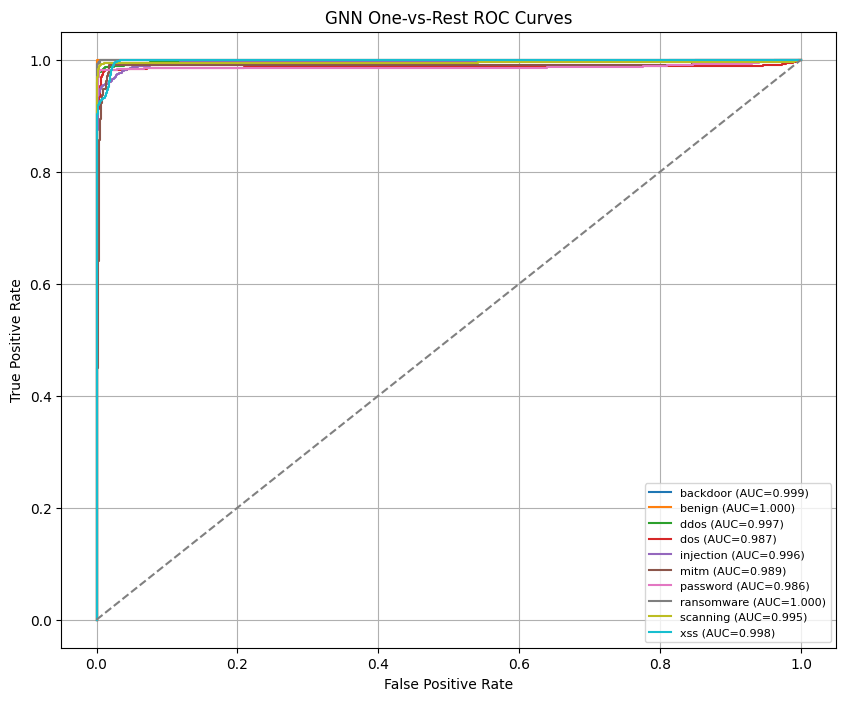

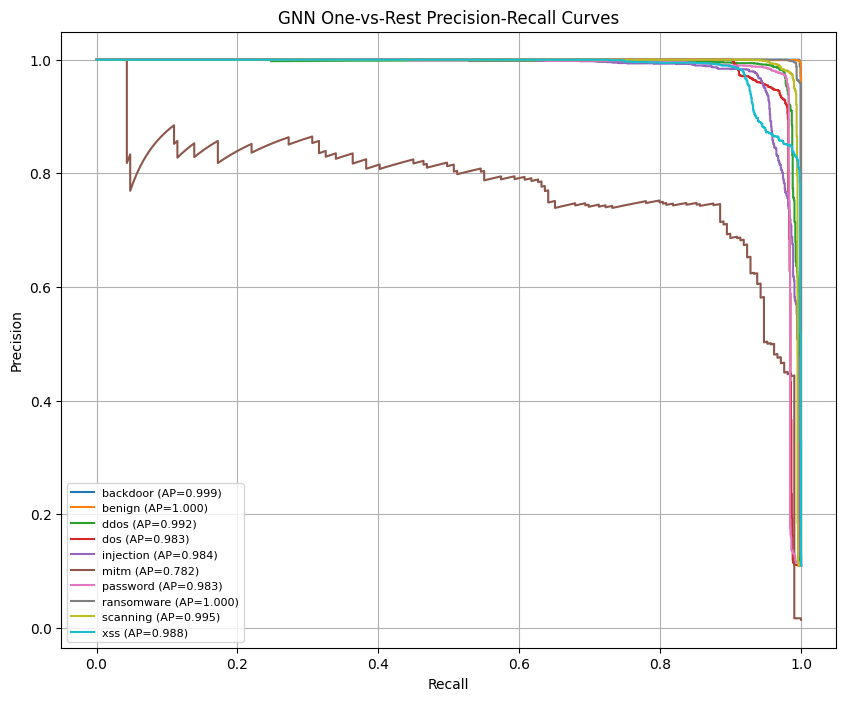

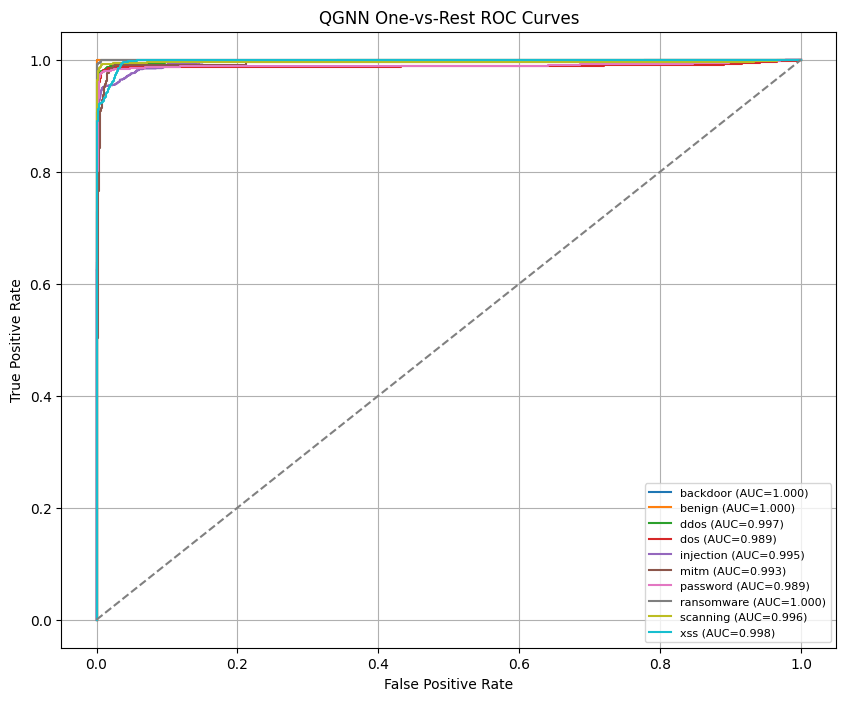

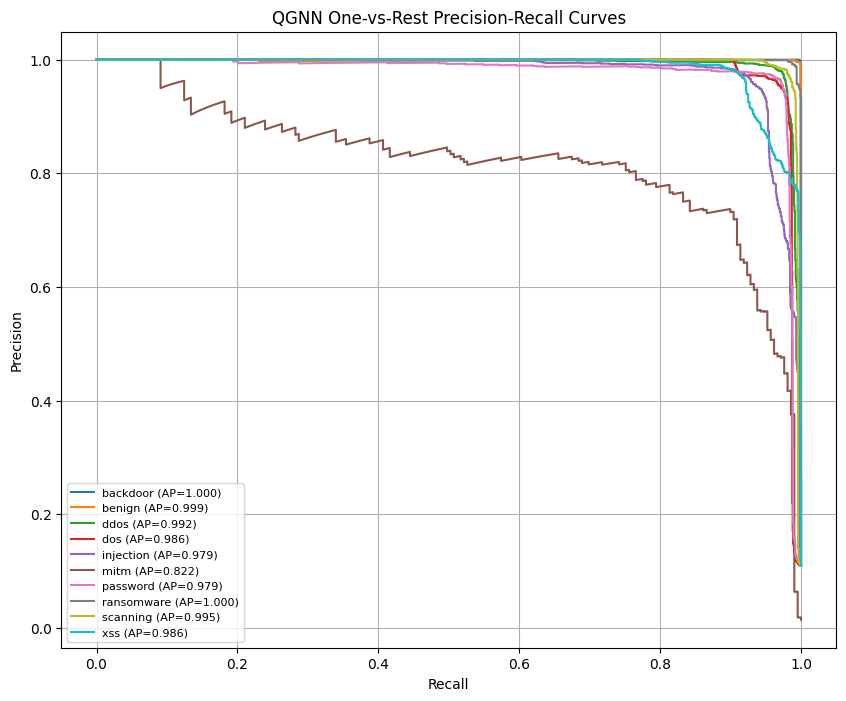

In [ ]:

# Cell 11 - ROC curves and Precision-Recall curves

y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))

def plot_multiclass_roc_and_pr(y_true_bin, y_prob, model_name):
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(label_encoder.classes_):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=1.5, label=f"{class_name} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} One-vs-Rest ROC Curves")
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(label_encoder.classes_):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(recall, precision, linewidth=1.5, label=f"{class_name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} One-vs-Rest Precision-Recall Curves")
    plt.legend(loc="lower left", fontsize=8)
    plt.grid(True)
    plt.show()

plot_multiclass_roc_and_pr(y_test_bin, test_metrics_gnn["y_prob"], "GNN")
plot_multiclass_roc_and_pr(y_test_bin, test_metrics_qgnn["y_prob"], "QGNN")


In [ ]:

# Cell 12 - Optional: save trained weights

torch.save({
    "selected_feature_names": selected_feature_names,
    "label_classes": list(label_encoder.classes_),
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
    "selector_support": selected_feature_mask,
    "gnn_state_dict": classical_model.state_dict(),
    "qgnn_state_dict": quantum_model.state_dict(),
}, "/content/qgnn_toniot_checkpoint.pth")

print("Saved checkpoint to /content/qgnn_toniot_checkpoint.pth")


Saved checkpoint to /content/qgnn_toniot_checkpoint.pth
